# BCI Competition IV-2a — Subject-Independent EEGNet + DANN + Euclidean Alignment

This notebook implements a **9-fold Leave-One-Subject-Out (LOSO)** cross-subject motor-imagery classifier for **BCI Competition IV dataset 2a**.

## Pipeline

**GDF → 22 EEG channels → 4–38 Hz bandpass → [2, 6) s epochs → Euclidean Alignment (EA) → EEGNet feature extractor →**

- **Task classifier:** 4-class motor imagery
- **Domain discriminator:** subject ID
- **Gradient Reversal Layer (GRL):** encourages subject-invariant features

### Important experimental note: Euclidean Alignment

The default configuration uses **transductive, unlabeled target-domain EA**:

- Source subjects: EA reference is computed from source training trials.
- Held-out target subject: EA reference is computed from the target's *unlabeled* trials before evaluation.
- No target motor-imagery labels are used during EA or DANN training.

This is a legitimate unsupervised adaptation setting, but it is **not the same as a strictly inductive unseen-user test** in which the target EEG is completely inaccessible until final evaluation.

For a stricter protocol, set `EA_TARGET_MODE = "identity"` and disable target-domain samples in the DANN loss.

### Dataset convention

The code loads `A01T.gdf ... A09T.gdf` by default. The official BCI Competition IV download page provides dataset 2a as GDF files.

The notebook uses event codes **769–772** for the four imagery classes and epochs with `TMIN=2.0` and `TMAX=6.0 - 1/sfreq`, giving exactly 4 seconds at 250 Hz (1000 time samples).

> If your copy of the GDF files uses a different annotation representation, the event-inspection cell will show the available annotations so the mapping can be adjusted.

## 0. Recommended environment

For a reproducible 2026 environment, the notebook is written against:

- Python **3.11**
- PyTorch **2.13.0**
- MNE-Python **1.12.1**
- Braindecode **1.7.0**
- MOABB **1.5.0**
- NumPy / SciPy / scikit-learn / pandas / matplotlib

Braindecode 1.7.0 requires Python >=3.11; MNE 1.12.1 requires Python >=3.10; MOABB 1.5.0 requires Python >=3.10.

For a MacBook Air M4, the notebook automatically uses Apple **MPS** when available, otherwise CUDA, otherwise CPU.

In [1]:
# CELL 1 — INSTALLATION
# Run once in a fresh environment.
# Restart the Jupyter kernel after installation if necessary.

import sys
import subprocess

packages = [
    "torch==2.13.0",
    "mne==1.12.1",
    "braindecode==1.7.0",
    "moabb==1.5.0",
    "numpy>=2.0,<3",
    "scipy>=1.14,<2",
    "scikit-learn>=1.5,<2",
    "pandas>=2.2,<4",
    "matplotlib>=3.9,<4",
    "seaborn>=0.13,<1",
    "tqdm>=4.66,<5",
    "pyyaml>=6,<7",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *packages])
print("Installation complete. Restart the kernel if packages were upgraded.")

  Using cached torch-2.13.0-cp310-cp310-macosx_14_0_arm64.whl.metadata (39 kB)
  Using cached mne-1.12.1-py3-none-any.whl.metadata (16 kB)


ERROR: Ignored the following yanked versions: 0.8
ERROR: Ignored the following versions that require a different python version: 1.3.0 Requires-Python >=3.11; 1.3.0.dev167809764 Requires-Python >=3.11; 1.3.0.dev168090315 Requires-Python >=3.11; 1.3.0.dev168639307 Requires-Python >=3.11; 1.3.0.dev168926291 Requires-Python >=3.11; 1.3.0.dev169765289 Requires-Python >=3.11; 1.3.0.dev171418921 Requires-Python >=3.11; 1.3.0.dev171607082 Requires-Python >=3.11; 1.3.0.dev171854083 Requires-Python >=3.11; 1.3.0.dev172315966 Requires-Python >=3.11; 1.3.0.dev173193230 Requires-Python >=3.11; 1.3.0.dev174201910 Requires-Python >=3.11; 1.3.0.dev175563314 Requires-Python >=3.11; 1.3.0.dev175863287 Requires-Python >=3.11; 1.3.0.dev175887834 Requires-Python >=3.11; 1.3.0.dev177069446 Requires-Python >=3.11; 1.3.0.dev179467414 Requires-Python >=3.11; 1.3.0.dev180760430 Requires-Python >=3.11; 1.3.0.dev181027669 Requires-Python >=3.11; 1.3.0.dev183173928 Requires-Python >=3.11; 1.3.0.dev183348003 Requi

CalledProcessError: Command '['/opt/anaconda3/envs/mtech_tf/bin/python', '-m', 'pip', 'install', '-U', 'torch==2.13.0', 'mne==1.12.1', 'braindecode==1.7.0', 'moabb==1.5.0', 'numpy>=2.0,<3', 'scipy>=1.14,<2', 'scikit-learn>=1.5,<2', 'pandas>=2.2,<4', 'matplotlib>=3.9,<4', 'seaborn>=0.13,<1', 'tqdm>=4.66,<5', 'pyyaml>=6,<7']' returned non-zero exit status 1.

In [1]:
# CELL 2 — IMPORTS, REPRODUCIBILITY, DEVICE

import os
import re
import math
import json
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

try:
    import braindecode
    print("Braindecode:", braindecode.__version__)
except Exception as exc:
    print("Braindecode import warning:", exc)

print("MNE:", mne.__version__)
print("PyTorch:", torch.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)

Braindecode import warning: No module named 'braindecode'
MNE: 1.11.0
PyTorch: 2.10.0
DEVICE: mps


In [4]:
# ============================================================
# CELL 3 — UPDATED CONFIGURATION
# ============================================================

from dataclasses import dataclass
from typing import Dict, Tuple, Optional


@dataclass
class Config:

    # --------------------------------------------------------
    # DATASET
    # --------------------------------------------------------

    DATA_ROOT: str = "./BCICIV_2a"

    SUBJECTS: Tuple[str, ...] = tuple(
        f"A{i:02d}" for i in range(1, 10)
    )

    # --------------------------------------------------------
    # EEG
    # --------------------------------------------------------

    N_CHANNELS: int = 22
    SFREQ: float = 250.0

    L_FREQ: float = 4.0
    H_FREQ: float = 38.0

    # Epoch [2.0, 6.0)
    TMIN: float = 2.0
    TMAX: float = 6.0

    # Event mapping
    EVENT_CODES: Dict[int, int] = None

    # --------------------------------------------------------
    # EUCLIDEAN ALIGNMENT
    # --------------------------------------------------------

    EA_EPS: float = 1e-6

    # Strict LOSO baseline:
    #
    # "identity"
    #     Target is NOT used to estimate EA.
    #
    # "transductive"
    #     Unlabeled target EEG is used for target EA.
    #
    EA_TARGET_MODE: str = "identity"

    # IMPORTANT:
    # Turn OFF initially.
    #
    # EA already normalizes covariance structure.
    # We first establish whether EA + EEGNet works
    # without another transformation.
    #
    USE_SOURCE_STANDARDIZATION: bool = False

    # --------------------------------------------------------
    # EEGNET
    # --------------------------------------------------------

    EEGNET_F1: int = 8
    EEGNET_D: int = 2
    EEGNET_F2: int = 16

    EEGNET_KERNEL_LENGTH: int = 64

    EEGNET_DROPOUT: float = 0.5

    # --------------------------------------------------------
    # DOMAIN DISCRIMINATOR
    # --------------------------------------------------------

    DOMAIN_HIDDEN_1: int = 128
    DOMAIN_HIDDEN_2: int = 64

    DOMAIN_DROPOUT: float = 0.3

    # IMPORTANT:
    # Disabled for the strict EEGNet baseline.
    #
    # Later we will enable this for DANN.
    #
    USE_TARGET_DOMAIN_SAMPLES: bool = False

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    EPOCHS: int = 80

    BATCH_SIZE: int = 64

    LR: float = 1e-3

    WEIGHT_DECAY: float = 1e-4

    # DANN parameter.
    # Not used in baseline.
    LAMBDA_MAX: float = 1.0

    ETA_MIN: float = 1e-5

    NUM_WORKERS: int = 0

    GRAD_CLIP_NORM: float = 5.0

    # --------------------------------------------------------
    # EXPERIMENT CONTROL
    # --------------------------------------------------------

    RUN_SMOKE_TEST: bool = False

    # Start with one LOSO fold.
    #
    # None -> all 9 subjects
    # 1    -> A01 only
    #
    MAX_FOLDS: Optional[int] = 1

    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    OUTPUT_DIR: str = "./outputs_eegnet_dann_ea"


CFG = Config()


# ------------------------------------------------------------
# CLASS MAPPING
# ------------------------------------------------------------

CFG.EVENT_CODES = {
    769: 0,   # Left hand
    770: 1,   # Right hand
    771: 2,   # Both feet
    772: 3,   # Tongue
}


# ------------------------------------------------------------
# EXACT EPOCH END
# ------------------------------------------------------------

CFG_TMAX = (
    CFG.TMAX
    - 1.0 / CFG.SFREQ
)


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

from pathlib import Path

Path(
    CFG.OUTPUT_DIR
).mkdir(
    parents=True,
    exist_ok=True,
)


print("=" * 70)
print("UPDATED CONFIGURATION")
print("=" * 70)

print(
    f"Dataset:                 {CFG.DATA_ROOT}"
)

print(
    f"Subjects:                {CFG.SUBJECTS}"
)

print(
    f"EEG channels:            {CFG.N_CHANNELS}"
)

print(
    f"Sampling frequency:      {CFG.SFREQ} Hz"
)

print(
    f"Bandpass:                {CFG.L_FREQ}-{CFG.H_FREQ} Hz"
)

print(
    f"Epoch:                   [{CFG.TMIN}, {CFG.TMAX}) s"
)

print(
    f"Target EA mode:          {CFG.EA_TARGET_MODE}"
)

print(
    f"Source standardization:  {CFG.USE_SOURCE_STANDARDIZATION}"
)

print(
    f"Target domain samples:   {CFG.USE_TARGET_DOMAIN_SAMPLES}"
)

print(
    f"Epochs:                  {CFG.EPOCHS}"
)

print(
    f"Batch size:              {CFG.BATCH_SIZE}"
)

print(
    f"Learning rate:           {CFG.LR}"
)

print(
    f"Max folds:               {CFG.MAX_FOLDS}"
)

print("=" * 70)

UPDATED CONFIGURATION
Dataset:                 ./BCICIV_2a
Subjects:                ('A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09')
EEG channels:            22
Sampling frequency:      250.0 Hz
Bandpass:                4.0-38.0 Hz
Epoch:                   [2.0, 6.0) s
Target EA mode:          identity
Source standardization:  False
Target domain samples:   False
Epochs:                  80
Batch size:              64
Learning rate:           0.001
Max folds:               1


## 1. Dataset layout

Download **BCI Competition IV dataset 2a** GDF files from the official competition download area and extract them so that the notebook can find:

```text
BCI_IV_2a/
├── A01T.gdf
├── A02T.gdf
├── ...
└── A09T.gdf
```

The loader recursively searches under `DATA_ROOT`, so a nested extraction directory is also accepted.

In [5]:
# CELL 4 — FILE DISCOVERY + BASIC DATASET CHECKS

DATA_ROOT = Path(CFG.DATA_ROOT)

def find_subject_file(subject_id: str, root: Path = DATA_ROOT) -> Path:
    patterns = [f"{subject_id}T.gdf", f"{subject_id.lower()}T.gdf"]
    for pattern in patterns:
        matches = list(root.rglob(pattern))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"Could not find {subject_id}T.gdf under {root.resolve()}"
    )

for sid in CFG.SUBJECTS:
    try:
        print(sid, "->", find_subject_file(sid))
    except FileNotFoundError as exc:
        print(exc)

A01 -> BCICIV_2a/A01T.gdf
A02 -> BCICIV_2a/A02T.gdf
A03 -> BCICIV_2a/A03T.gdf
A04 -> BCICIV_2a/A04T.gdf
A05 -> BCICIV_2a/A05T.gdf
A06 -> BCICIV_2a/A06T.gdf
A07 -> BCICIV_2a/A07T.gdf
A08 -> BCICIV_2a/A08T.gdf
A09 -> BCICIV_2a/A09T.gdf


In [6]:
# CELL 5 — INSPECT ONE GDF FILE

TEST_SUBJECT = CFG.SUBJECTS[0]
test_path = find_subject_file(TEST_SUBJECT)

raw_inspect = mne.io.read_raw_gdf(test_path, preload=False, verbose="ERROR")

print(raw_inspect)
print("\nSampling frequency:", raw_inspect.info["sfreq"])
print("\nChannel types:")
print(pd.Series(raw_inspect.get_channel_types()).value_counts())

print("\nChannel names:")
print(raw_inspect.ch_names)

print("\nAnnotations:")
print(raw_inspect.annotations)

events_preview, event_id_preview = mne.events_from_annotations(
    raw_inspect, verbose="ERROR"
)

print("\nEvent mapping:")
print(event_id_preview)
print("\nUnique event codes in events:")
print(np.unique(events_preview[:, 2]))

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~29 KiB, data not loaded>

Sampling frequency: 250.0

Channel types:
eeg    25
Name: count, dtype: int64

Channel names:
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']

Annotations:
<Annotations | 603 segments: 1023 (15), 1072 (1), 276 (1), 277 (1), 32766 ...>

Event mapping:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}

Unique event codes in events:
[ 1  2  3  4  5  6  7  8  9 10]


In [7]:
# CELL 6 — ROBUST EVENT EXTRACTION

def numeric_annotation_events(raw: mne.io.BaseRaw) -> np.ndarray:
    sfreq = raw.info["sfreq"]
    rows = []

    for onset, duration, desc in zip(
        raw.annotations.onset,
        raw.annotations.duration,
        raw.annotations.description,
    ):
        match = re.search(r"(\d+(?:\.\d+)?)", str(desc))
        if not match:
            continue
        value = float(match.group(1))
        if not value.is_integer():
            continue
        code_value = int(value)
        sample = int(round(float(onset) * sfreq))
        rows.append([sample, 0, code_value])

    if not rows:
        raise RuntimeError("No numeric annotations were found.")

    return np.asarray(rows, dtype=np.int64)


def extract_mi_events(raw: mne.io.BaseRaw) -> np.ndarray:
    events = numeric_annotation_events(raw)
    keep = np.isin(events[:, 2], list(CFG.EVENT_CODES.keys()))
    mi_events = events[keep].copy()

    if len(mi_events) == 0:
        raise RuntimeError(
            "No 769-772 events found. Inspect raw.annotations and "
            "event mapping in the previous cell."
        )
    return mi_events

In [8]:
# ============================================================
# CELL 7 — UPDATED DATA LOADER
# ============================================================

CLASS_NAMES = [
    "Left hand",
    "Right hand",
    "Both feet",
    "Tongue",
]


# ------------------------------------------------------------
# Explicitly exclude EOG channels
# ------------------------------------------------------------

EOG_CHANNELS = {
    "EOG-left",
    "EOG-central",
    "EOG-right",
}


def load_subject_epochs(
    subject_id: str,
) -> Tuple[np.ndarray, np.ndarray]:

    """
    Load one BCI Competition IV-2a subject.

    Processing:
        1. Read GDF
        2. Select exactly 22 EEG channels
        3. Bandpass 4-38 Hz
        4. Extract events 769-772
        5. Epoch [2.0, 6.0)
        6. Return float32 NumPy arrays

    Returns
    -------
    X : np.ndarray
        Shape:
            (n_trials, 22, 1000)

    y : np.ndarray
        Shape:
            (n_trials,)
    """

    # --------------------------------------------------------
    # 1. Locate subject file
    # --------------------------------------------------------

    path = find_subject_file(
        subject_id
    )

    print(
        f"\nLoading subject {subject_id}"
    )

    print(
        f"File: {path}"
    )


    # --------------------------------------------------------
    # 2. Load GDF
    # --------------------------------------------------------

    raw = mne.io.read_raw_gdf(
        path,
        preload=True,
        verbose="ERROR",
    )

    print(
        f"Original channel count: "
        f"{len(raw.ch_names)}"
    )


    # --------------------------------------------------------
    # 3. Explicit EEG channel selection
    # --------------------------------------------------------

    eeg_channels = [
        ch
        for ch in raw.ch_names
        if ch not in EOG_CHANNELS
    ]


    print(
        f"Detected EEG channels: "
        f"{len(eeg_channels)}"
    )


    if len(eeg_channels) != CFG.N_CHANNELS:

        raise ValueError(

            f"{subject_id}: expected "
            f"{CFG.N_CHANNELS} EEG channels "
            f"but found "
            f"{len(eeg_channels)}.\n\n"

            f"Selected channels:\n"
            f"{eeg_channels}\n\n"

            f"Original channels:\n"
            f"{raw.ch_names}"
        )


    # --------------------------------------------------------
    # Keep exactly 22 EEG channels
    # --------------------------------------------------------

    raw.pick(
        eeg_channels
    )


    # --------------------------------------------------------
    # 4. Sampling frequency check
    # --------------------------------------------------------

    actual_sfreq = float(
        raw.info["sfreq"]
    )


    print(
        f"Sampling frequency: "
        f"{actual_sfreq} Hz"
    )


    if not np.isclose(
        actual_sfreq,
        CFG.SFREQ,
    ):

        raise ValueError(

            f"{subject_id}: expected "
            f"{CFG.SFREQ} Hz but found "
            f"{actual_sfreq} Hz."
        )


    # --------------------------------------------------------
    # 5. Bandpass filtering
    # --------------------------------------------------------

    print(
        f"Applying {CFG.L_FREQ}-"
        f"{CFG.H_FREQ} Hz bandpass..."
    )


    raw.filter(
        l_freq=CFG.L_FREQ,
        h_freq=CFG.H_FREQ,

        method="fir",

        phase="zero",

        verbose="ERROR",
    )


    # --------------------------------------------------------
    # 6. Extract motor imagery events
    # --------------------------------------------------------

    mi_events = extract_mi_events(
        raw
    )


    print(
        f"Motor imagery events: "
        f"{len(mi_events)}"
    )


    # --------------------------------------------------------
    # 7. Event mapping
    # --------------------------------------------------------

    event_id = {

        "Left hand": 769,

        "Right hand": 770,

        "Both feet": 771,

        "Tongue": 772,
    }


    # --------------------------------------------------------
    # 8. Epoching
    # --------------------------------------------------------

    epochs = mne.Epochs(

        raw,

        mi_events,

        event_id=event_id,

        tmin=CFG.TMIN,

        tmax=CFG_TMAX,

        baseline=None,

        preload=True,

        reject_by_annotation=True,

        verbose="ERROR",
    )


    # --------------------------------------------------------
    # 9. Convert labels
    # --------------------------------------------------------

    inv_event_id = {

        769: 0,

        770: 1,

        771: 2,

        772: 3,
    }


    y = np.asarray(

        [
            inv_event_id[
                int(event_code)
            ]

            for event_code
            in epochs.events[:, 2]
        ],

        dtype=np.int64,
    )


    # --------------------------------------------------------
    # 10. EEG data
    # --------------------------------------------------------

    X = epochs.get_data(
        copy=True
    ).astype(
        np.float32
    )


    # --------------------------------------------------------
    # 11. Expected shape
    # --------------------------------------------------------

    expected_samples = int(
        round(
            (
                CFG.TMAX
                - CFG.TMIN
            )
            * CFG.SFREQ
        )
    )


    # --------------------------------------------------------
    # 12. Shape validation
    # --------------------------------------------------------

    if X.shape[1] != CFG.N_CHANNELS:

        raise ValueError(

            f"{subject_id}: "
            f"expected "
            f"{CFG.N_CHANNELS} EEG channels "

            f"but got "
            f"{X.shape[1]}."
        )


    if X.shape[2] != expected_samples:

        raise ValueError(

            f"{subject_id}: "
            f"expected "
            f"{expected_samples} samples "

            f"but got "
            f"{X.shape[2]}."
        )


    # --------------------------------------------------------
    # 13. Class distribution
    # --------------------------------------------------------

    class_counts = np.bincount(
        y,
        minlength=4,
    )


    print(
        f"Final shape: {X.shape}"
    )


    print(
        "Class distribution:"
    )


    for idx, name in enumerate(
        CLASS_NAMES
    ):

        print(
            f"  {idx} | "
            f"{name:12s} | "
            f"{class_counts[idx]}"
        )


    return X, y

## 2. Euclidean Alignment (EA)

For each subject, compute the arithmetic mean covariance of the trials:

\[
R_s = \frac{1}{N_s}\sum_i C(X_i)
\]

and whiten every trial with

\[
X_i^{EA} = R_s^{-1/2} X_i.
\]

This makes the subject-wise average covariance approximately identity and reduces first-order covariance differences between subjects.

The source alignment matrices are fitted only from source-training trials. In the default **transductive** target mode, the target alignment matrix uses target EEG without using motor-imagery labels.

In [9]:
# ============================================================
# CELL 8 — EUCLIDEAN ALIGNMENT
# ============================================================

def trial_covariance(
    X: np.ndarray,
    eps: float = 1e-6,
) -> np.ndarray:

    """
    Compute average covariance across EEG trials.

    X:
        (n_trials, n_channels, n_times)
    """

    X = np.asarray(
        X,
        dtype=np.float64,
    )


    if X.ndim != 3:

        raise ValueError(
            f"Expected 3-D X, got {X.shape}"
        )


    n_trials, n_channels, _ = X.shape


    R = np.zeros(
        (
            n_channels,
            n_channels,
        ),
        dtype=np.float64,
    )


    for trial in X:

        # Remove per-channel temporal mean
        trial = (
            trial
            - trial.mean(
                axis=1,
                keepdims=True,
            )
        )


        covariance = (
            trial @ trial.T
        )


        covariance /= max(
            trial.shape[1] - 1,
            1,
        )


        R += covariance


    R /= n_trials


    # Numerical regularization
    trace_scale = (
        np.trace(R)
        / n_channels
    )


    R += (
        eps
        * trace_scale
        * np.eye(
            n_channels
        )
    )


    return R


def inv_sqrtm_spd(
    M: np.ndarray,
    eps: float = 1e-10,
) -> np.ndarray:

    """
    Symmetric inverse square root:

        M^(-1/2)
    """

    eigvals, eigvecs = np.linalg.eigh(
        M
    )


    eigvals = np.clip(
        eigvals,
        eps,
        None,
    )


    inv_sqrt = (
        eigvecs
        * (1.0 / np.sqrt(eigvals))
    ) @ eigvecs.T


    return inv_sqrt


def fit_ea(
    X: np.ndarray,
    eps: float = 1e-6,
) -> Dict[str, np.ndarray]:

    """
    Fit Euclidean Alignment transform
    for one subject.
    """

    R = trial_covariance(
        X,
        eps=eps,
    )


    W = inv_sqrtm_spd(
        R
    )


    return {

        "R": R.astype(
            np.float32
        ),

        "W": W.astype(
            np.float32
        ),
    }


def apply_ea(
    X: np.ndarray,
    W: np.ndarray,
) -> np.ndarray:

    """
    Apply:

        X_EA = W @ X

    independently to every trial.
    """

    return np.einsum(
        "ij,njt->nit",
        W,
        X,
    ).astype(
        np.float32
    )


def check_ea_alignment(
    X_ea: np.ndarray,
) -> float:

    """
    Measure how close the average covariance
    is to the identity matrix.
    """

    R = trial_covariance(
        X_ea
    )


    I = np.eye(
        R.shape[0]
    )


    numerator = np.linalg.norm(
        R - I,
        ord="fro",
    )


    denominator = np.linalg.norm(
        I,
        ord="fro",
    )


    return float(
        numerator / denominator
    )

In [10]:
# ============================================================
# CELL 9 — SOURCE-ONLY STANDARDIZATION
# ============================================================

@dataclass
class SourceScaler:

    mean: np.ndarray

    std: np.ndarray


def fit_source_scaler(
    source_X: List[np.ndarray],
) -> SourceScaler:

    """
    Fit normalization parameters using SOURCE
    subjects only.

    Never fit these statistics using target labels
    or target EEG in strict LOSO mode.
    """

    if len(source_X) == 0:

        raise ValueError(
            "source_X is empty."
        )


    concat = np.concatenate(
        source_X,
        axis=0,
    ).astype(
        np.float64
    )


    # Shape:
    # (1, channels, 1)

    mean = concat.mean(
        axis=(0, 2),
        keepdims=True,
    )


    std = concat.std(
        axis=(0, 2),
        keepdims=True,
    )


    std = np.maximum(
        std,
        1e-6,
    )


    return SourceScaler(

        mean=mean.astype(
            np.float32
        ),

        std=std.astype(
            np.float32
        ),
    )


def apply_source_scaler(
    X: np.ndarray,
    scaler: SourceScaler,
) -> np.ndarray:

    return (
        (
            X
            - scaler.mean
        )
        / scaler.std
    ).astype(
        np.float32
    )

In [11]:
# CELL 10 — PRELOAD ALL SUBJECTS

ALL_SUBJECT_DATA: Dict[str, Dict[str, np.ndarray]] = {}

for sid in tqdm(CFG.SUBJECTS, desc="Loading all subjects"):
    X, y = load_subject_epochs(sid)
    ALL_SUBJECT_DATA[sid] = {"X": X, "y": y}
    print(
        f"{sid}: X={X.shape}, "
        f"class_counts={np.bincount(y, minlength=4).tolist()}"
    )

Loading all subjects:   0%|          | 0/9 [00:00<?, ?it/s]


Loading subject A01
File: BCICIV_2a/A01T.gdf
Original channel count: 25
Detected EEG channels: 22
Sampling frequency: 250.0 Hz
Applying 4.0-38.0 Hz bandpass...
Motor imagery events: 288
Final shape: (287, 22, 1000)
Class distribution:
  0 | Left hand    | 71
  1 | Right hand   | 72
  2 | Both feet    | 72
  3 | Tongue       | 72
A01: X=(287, 22, 1000), class_counts=[71, 72, 72, 72]

Loading subject A02
File: BCICIV_2a/A02T.gdf
Original channel count: 25
Detected EEG channels: 22
Sampling frequency: 250.0 Hz
Applying 4.0-38.0 Hz bandpass...
Motor imagery events: 288
Final shape: (287, 22, 1000)
Class distribution:
  0 | Left hand    | 72
  1 | Right hand   | 72
  2 | Both feet    | 71
  3 | Tongue       | 72
A02: X=(287, 22, 1000), class_counts=[72, 72, 71, 72]

Loading subject A03
File: BCICIV_2a/A03T.gdf
Original channel count: 25
Detected EEG channels: 22
Sampling frequency: 250.0 Hz
Applying 4.0-38.0 Hz bandpass...
Motor imagery events: 288
Final shape: (287, 22, 1000)
Class distri

In [12]:
# CELL 11 — OPTIONAL EA SANITY CHECK

sid = TEST_SUBJECT
X_raw = ALL_SUBJECT_DATA[sid]["X"]

ea_test = fit_ea(X_raw, eps=CFG.EA_EPS)
X_ea_test = apply_ea(X_raw, ea_test["W"])

before_R = trial_covariance(X_raw)
after_R = trial_covariance(X_ea_test)

print(
    "Before EA distance to identity:",
    np.linalg.norm(before_R - np.eye(CFG.N_CHANNELS))
    / np.sqrt(CFG.N_CHANNELS),
)
print("After EA distance to identity:", check_ea_alignment(X_ea_test))

Before EA distance to identity: 0.9999999997789548
After EA distance to identity: 0.9042630787823993


## 3. PyTorch datasets

Each training example contains:

- EEG tensor
- task label: 0–3 for source trials, **-1 for unlabeled target trials**
- domain label: subject index 0–8

The domain discriminator therefore gets subject metadata for both source and target, while the task classifier is trained **only on source labels**.

In [13]:
# ============================================================
# CELL 12 — UPDATED LOSO DATA PREPARATION
# ============================================================

class DANNSubjectDataset(
    Dataset
):

    def __init__(
        self,
        X: np.ndarray,
        y_task: np.ndarray,
        y_domain: np.ndarray,
    ):

        if X.ndim != 3:

            raise ValueError(
                f"X must be 3-D, got {X.shape}"
            )


        if not (
            len(X)
            == len(y_task)
            == len(y_domain)
        ):

            raise ValueError(
                "X, y_task and y_domain "
                "must have equal length."
            )


        # EEGNet input:
        #
        # (N, 1, Channels, Time)

        self.X = torch.from_numpy(
            X[:, None, :, :]
        ).float()


        self.y_task = torch.from_numpy(
            y_task
        ).long()


        self.y_domain = torch.from_numpy(
            y_domain
        ).long()


    def __len__(self):

        return len(
            self.X
        )


    def __getitem__(
        self,
        idx,
    ):

        return (
            self.X[idx],
            self.y_task[idx],
            self.y_domain[idx],
        )


def prepare_loso_fold(
    target_subject: str,
) -> Tuple[
    DANNSubjectDataset,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:

    """
    Prepare strict LOSO fold.

    Source:
        8 subjects

    Target:
        1 subject

    In strict mode, target EEG is NEVER added
    to the training dataset.
    """

    # --------------------------------------------------------
    # Source subjects
    # --------------------------------------------------------

    source_subjects = [

        sid

        for sid in CFG.SUBJECTS

        if sid != target_subject

    ]


    print(
        f"\nTarget subject: "
        f"{target_subject}"
    )


    print(
        "Source subjects:",
        source_subjects,
    )


    # --------------------------------------------------------
    # SOURCE PROCESSING
    # --------------------------------------------------------

    source_processed = []

    source_labels = []

    source_domains = []


    for sid in source_subjects:

        X_raw = (
            ALL_SUBJECT_DATA[
                sid
            ]["X"]
        )


        y = (
            ALL_SUBJECT_DATA[
                sid
            ]["y"]
        )


        # --------------------------------------------
        # EA fitted independently per source subject
        # --------------------------------------------

        ea = fit_ea(
            X_raw,
            eps=CFG.EA_EPS,
        )


        X_ea = apply_ea(
            X_raw,
            ea["W"],
        )


        source_processed.append(
            X_ea
        )


        source_labels.append(
            y
        )


        source_domains.append(

            np.full(

                len(X_ea),

                CFG.SUBJECTS.index(
                    sid
                ),

                dtype=np.int64,
            )
        )


    # --------------------------------------------------------
    # TARGET PROCESSING
    # --------------------------------------------------------

    X_target_raw = (
        ALL_SUBJECT_DATA[
            target_subject
        ]["X"]
    )


    y_target = (
        ALL_SUBJECT_DATA[
            target_subject
        ]["y"]
    )


    # --------------------------------------------------------
    # Strict LOSO:
    #
    # target is NOT used to estimate EA.
    #
    # Therefore:
    #
    # X_target remains raw filtered EEG here.
    # --------------------------------------------------------

    if CFG.EA_TARGET_MODE == "identity":

        X_target = (
            X_target_raw.copy()
        )


    elif CFG.EA_TARGET_MODE == "transductive":

        target_ea = fit_ea(

            X_target_raw,

            eps=CFG.EA_EPS,
        )


        X_target = apply_ea(

            X_target_raw,

            target_ea["W"],
        )


    else:

        raise ValueError(

            f"Invalid "
            f"EA_TARGET_MODE: "
            f"{CFG.EA_TARGET_MODE}"
        )


    # --------------------------------------------------------
    # OPTIONAL SOURCE STANDARDIZATION
    #
    # Disabled in the current baseline.
    # --------------------------------------------------------

    if CFG.USE_SOURCE_STANDARDIZATION:

        scaler = fit_source_scaler(
            source_processed
        )


        source_processed = [

            apply_source_scaler(
                X,
                scaler,
            )

            for X
            in source_processed

        ]


        X_target = apply_source_scaler(
            X_target,
            scaler,
        )


    # --------------------------------------------------------
    # Build SOURCE training dataset
    # --------------------------------------------------------

    X_train = np.concatenate(

        source_processed,

        axis=0,
    )


    y_train = np.concatenate(

        source_labels,

        axis=0,
    )


    domain_train = np.concatenate(

        source_domains,

        axis=0,
    )


    # --------------------------------------------------------
    # IMPORTANT
    #
    # Target samples are added ONLY when explicitly
    # requested for transductive DANN.
    # --------------------------------------------------------

    if CFG.USE_TARGET_DOMAIN_SAMPLES:

        X_train = np.concatenate(

            [
                X_train,
                X_target,
            ],

            axis=0,
        )


        y_train = np.concatenate(

            [
                y_train,

                np.full(
                    len(X_target),
                    -1,
                    dtype=np.int64,
                ),
            ],

            axis=0,
        )


        domain_train = np.concatenate(

            [
                domain_train,

                np.full(

                    len(X_target),

                    CFG.SUBJECTS.index(
                        target_subject
                    ),

                    dtype=np.int64,
                ),
            ],

            axis=0,
        )


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    dataset = DANNSubjectDataset(

        X_train,

        y_train,

        domain_train,
    )


    print(
        "Training samples:",
        len(dataset),
    )


    print(
        "Target samples:",
        len(X_target),
    )


    print(
        "Target used for training:",
        CFG.USE_TARGET_DOMAIN_SAMPLES,
    )


    return (
        dataset,
        X_target,
        y_target,
        np.asarray(
            source_subjects
        ),
    )

## 4. EEGNet feature extractor

The feature extractor follows the core Lawhern-style EEGNet pattern:

1. Temporal convolution.
2. Depthwise spatial convolution across the 22 EEG channels.
3. Average pooling + dropout.
4. Depthwise separable temporal convolution.
5. Average pooling + dropout.
6. Flatten to a compact feature vector.

The implementation is written directly in PyTorch so the GRL and dual-head DANN architecture remain explicit.

In [14]:
# ============================================================
# CELL 13 — GRADIENT REVERSAL LAYER
# ============================================================

class GradientReversalFunction(
    Function
):

    @staticmethod
    def forward(
        ctx,
        x,
        coeff,
    ):

        ctx.coeff = float(
            coeff
        )

        return x.view_as(x)


    @staticmethod
    def backward(
        ctx,
        grad_output,
    ):

        return (
            -ctx.coeff * grad_output,
            None,
        )


def grad_reverse(
    x,
    coeff=1.0,
):

    return GradientReversalFunction.apply(
        x,
        coeff,
    )

In [15]:
# ============================================================
# CELL 14 — EEGNET FEATURE EXTRACTOR
# + TASK CLASSIFIER
# + DOMAIN DISCRIMINATOR
# ============================================================

class EEGNetFeatureExtractor(
    nn.Module
):

    def __init__(
        self,

        n_channels=22,

        n_times=1000,

        F1=8,

        D=2,

        F2=16,

        kernel_length=64,

        dropout=0.5,
    ):

        super().__init__()


        self.n_channels = (
            n_channels
        )

        self.n_times = (
            n_times
        )


        # ----------------------------------------------------
        # BLOCK 1
        # Temporal convolution
        # ----------------------------------------------------

        self.temporal = nn.Conv2d(

            in_channels=1,

            out_channels=F1,

            kernel_size=(
                1,
                kernel_length,
            ),

            padding=(
                0,
                kernel_length // 2,
            ),

            bias=False,
        )


        self.bn1 = nn.BatchNorm2d(
            F1
        )


        # ----------------------------------------------------
        # DEPTHWISE SPATIAL CONVOLUTION
        # ----------------------------------------------------

        self.depthwise = nn.Conv2d(

            in_channels=F1,

            out_channels=F1 * D,

            kernel_size=(
                n_channels,
                1,
            ),

            groups=F1,

            bias=False,
        )


        self.bn2 = nn.BatchNorm2d(
            F1 * D
        )


        self.pool1 = nn.AvgPool2d(
            kernel_size=(1, 4)
        )


        self.drop1 = nn.Dropout(
            dropout
        )


        # ----------------------------------------------------
        # BLOCK 2
        # Depthwise separable convolution
        # ----------------------------------------------------

        self.sep_depthwise = nn.Conv2d(

            in_channels=F1 * D,

            out_channels=F1 * D,

            kernel_size=(
                1,
                16,
            ),

            padding=(
                0,
                8,
            ),

            groups=F1 * D,

            bias=False,
        )


        self.sep_pointwise = nn.Conv2d(

            in_channels=F1 * D,

            out_channels=F2,

            kernel_size=(1, 1),

            bias=False,
        )


        self.bn3 = nn.BatchNorm2d(
            F2
        )


        self.pool2 = nn.AvgPool2d(
            kernel_size=(1, 8)
        )


        self.drop2 = nn.Dropout(
            dropout
        )


        # ----------------------------------------------------
        # Automatically calculate feature dimension
        # ----------------------------------------------------

        self.feature_dim = (
            self._infer_feature_dim()
        )


    def _forward_conv(
        self,
        x,
    ):

        # -----------------------------------------------
        # Temporal
        # -----------------------------------------------

        x = self.temporal(x)

        x = self.bn1(x)


        # -----------------------------------------------
        # Depthwise spatial
        # -----------------------------------------------

        x = self.depthwise(x)

        x = self.bn2(x)

        x = F.elu(x)

        x = self.pool1(x)

        x = self.drop1(x)


        # -----------------------------------------------
        # Separable convolution
        # -----------------------------------------------

        x = self.sep_depthwise(x)

        x = self.sep_pointwise(x)

        x = self.bn3(x)

        x = F.elu(x)

        x = self.pool2(x)

        x = self.drop2(x)


        return x


    def _infer_feature_dim(
        self,
    ):

        was_training = (
            self.training
        )


        self.eval()


        with torch.no_grad():

            dummy = torch.zeros(

                1,

                1,

                self.n_channels,

                self.n_times,
            )


            output = (
                self._forward_conv(
                    dummy
                )
            )


            feature_dim = int(
                np.prod(
                    output.shape[
                        1:
                    ]
                )
            )


        if was_training:

            self.train()


        return feature_dim


    def forward(
        self,
        x,
    ):

        x = self._forward_conv(
            x
        )


        return torch.flatten(
            x,
            start_dim=1,
        )


class EEGNetDANN(
    nn.Module
):

    def __init__(
        self,

        n_channels=22,

        n_times=1000,

        n_classes=4,

        n_domains=9,

        F1=8,

        D=2,

        F2=16,

        kernel_length=64,

        dropout=0.5,

        domain_hidden_1=128,

        domain_hidden_2=64,

        domain_dropout=0.3,
    ):

        super().__init__()


        # ----------------------------------------------------
        # Feature extractor
        # ----------------------------------------------------

        self.feature_extractor = (
            EEGNetFeatureExtractor(

                n_channels=n_channels,

                n_times=n_times,

                F1=F1,

                D=D,

                F2=F2,

                kernel_length=kernel_length,

                dropout=dropout,
            )
        )


        feature_dim = (
            self.feature_extractor.feature_dim
        )


        # ----------------------------------------------------
        # TASK CLASSIFIER
        # ----------------------------------------------------

        self.task_classifier = nn.Sequential(

            nn.Linear(
                feature_dim,
                64,
            ),

            nn.ELU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                64,
                n_classes,
            ),
        )


        # ----------------------------------------------------
        # DOMAIN CLASSIFIER
        # ----------------------------------------------------

        self.domain_discriminator = nn.Sequential(

            nn.Linear(
                feature_dim,
                domain_hidden_1,
            ),

            nn.ELU(),

            nn.Dropout(
                domain_dropout
            ),

            nn.Linear(
                domain_hidden_1,
                domain_hidden_2,
            ),

            nn.ELU(),

            nn.Dropout(
                domain_dropout
            ),

            nn.Linear(
                domain_hidden_2,
                n_domains,
            ),
        )


    def forward(
        self,
        x,
        grl_coeff=1.0,
    ):

        # ----------------------------------------------------
        # EEGNet features
        # ----------------------------------------------------

        features = (
            self.feature_extractor(
                x
            )
        )


        # ----------------------------------------------------
        # TASK
        # ----------------------------------------------------

        task_logits = (
            self.task_classifier(
                features
            )
        )


        # ----------------------------------------------------
        # DOMAIN
        # ----------------------------------------------------

        reversed_features = (
            grad_reverse(
                features,
                coeff=grl_coeff,
            )
        )


        domain_logits = (
            self.domain_discriminator(
                reversed_features
            )
        )


        return (
            task_logits,
            domain_logits,
            features,
        )

## 5. DANN training

The requested objective is implemented as:

\[
L = L_{\text{task}} + \lambda(p)L_{\text{domain}}
\]

with the standard DANN schedule:

\[
\lambda(p)=\lambda_{\max}
\left(\frac{2}{1+\exp(-10p)}-1\right)
\]

where \(p\) increases from 0 to 1 over training.

The GRL itself uses coefficient **1.0**, while the scalar `lambda` multiplies the domain loss. This avoids applying the same coefficient twice.

In [16]:
# ============================================================
# CELL 15 — UPDATED TRAINING HELPERS
# ============================================================

def make_dataloader(
    dataset,
    shuffle=True,
):

    return DataLoader(

        dataset,

        batch_size=CFG.BATCH_SIZE,

        shuffle=shuffle,

        num_workers=CFG.NUM_WORKERS,

        pin_memory=(
            DEVICE.type == "cuda"
        ),

        drop_last=False,
    )


def build_model():

    model = EEGNetDANN(

        n_channels=CFG.N_CHANNELS,

        n_times=int(
            round(
                (
                    CFG.TMAX
                    - CFG.TMIN
                )
                * CFG.SFREQ
            )
        ),

        n_classes=4,

        n_domains=len(
            CFG.SUBJECTS
        ),

        F1=CFG.EEGNET_F1,

        D=CFG.EEGNET_D,

        F2=CFG.EEGNET_F2,

        kernel_length=(
            CFG.EEGNET_KERNEL_LENGTH
        ),

        dropout=(
            CFG.EEGNET_DROPOUT
        ),

        domain_hidden_1=(
            CFG.DOMAIN_HIDDEN_1
        ),

        domain_hidden_2=(
            CFG.DOMAIN_HIDDEN_2
        ),

        domain_dropout=(
            CFG.DOMAIN_DROPOUT
        ),
    )


    return model.to(
        DEVICE
    )


def evaluate_target(
    model,
    X_target,
    y_target,
):

    model.eval()

    predictions = []


    with torch.no_grad():

        for start in range(

            0,

            len(X_target),

            CFG.BATCH_SIZE,
        ):

            end = (
                start
                + CFG.BATCH_SIZE
            )


            X_batch = (
                torch.from_numpy(

                    X_target[
                        start:end,
                        None,
                        :,
                        :
                    ]

                )
                .float()
                .to(DEVICE)
            )


            task_logits, _, _ = (
                model(
                    X_batch,
                    grl_coeff=0.0,
                )
            )


            prediction = (

                task_logits

                .argmax(
                    dim=1
                )

                .cpu()

                .numpy()
            )


            predictions.append(
                prediction
            )


    y_pred = np.concatenate(
        predictions
    )


    return {

        "accuracy": float(

            accuracy_score(
                y_target,
                y_pred,
            )
        ),

        "balanced_accuracy": float(

            balanced_accuracy_score(
                y_target,
                y_pred,
            )
        ),

        "macro_f1": float(

            f1_score(

                y_target,

                y_pred,

                average="macro",

                zero_division=0,
            )
        ),

        "y_true": y_target.copy(),

        "y_pred": y_pred,

        "confusion_matrix":
            confusion_matrix(

                y_target,

                y_pred,

                labels=[
                    0,
                    1,
                    2,
                    3,
                ],
            ),
    }


def dann_lambda(
    progress,
    lambda_max=1.0,
):

    progress = float(
        np.clip(
            progress,
            0.0,
            1.0,
        )
    )


    return float(

        lambda_max

        * (

            2.0
            /
            (
                1.0
                + np.exp(
                    -10.0
                    * progress
                )
            )

            - 1.0
        )
    )

In [17]:
# ============================================================
# CELL 16 — EEGNET + EA BASELINE
#
# IMPORTANT:
# DANN IS DISABLED HERE.
#
# Goal:
# Establish whether EEGNet can learn the MI task
# before introducing adversarial training.
# ============================================================

def train_one_fold(
    target_subject,
    verbose=True,
):

    print("\n")
    print("=" * 80)
    print(
        f"TARGET SUBJECT: {target_subject}"
    )
    print("=" * 80)


    # --------------------------------------------------------
    # Prepare LOSO fold
    # --------------------------------------------------------

    (
        train_ds,
        X_target,
        y_target,
        source_subjects,
    ) = prepare_loso_fold(
        target_subject
    )


    # --------------------------------------------------------
    # Source DataLoader
    # --------------------------------------------------------

    loader = make_dataloader(
        train_ds,
        shuffle=True,
    )


    # --------------------------------------------------------
    # Build EEGNet
    # --------------------------------------------------------

    model = build_model()


    print(
        "\nModel device:",
        DEVICE,
    )


    print(
        "Number of trainable parameters:",
        sum(
            p.numel()
            for p in model.parameters()
            if p.requires_grad
        ),
    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=CFG.LR,

        weight_decay=CFG.WEIGHT_DECAY,
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=CFG.EPOCHS,

            eta_min=CFG.ETA_MIN,
        )
    )


    # --------------------------------------------------------
    # TASK LOSS
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history = []


    # --------------------------------------------------------
    # Checkpointing
    # --------------------------------------------------------

    best_source_acc = -np.inf

    best_epoch = -1

    best_state = None


    # --------------------------------------------------------
    # EPOCH LOOP
    # --------------------------------------------------------

    for epoch in range(
        CFG.EPOCHS
    ):

        model.train()


        running_loss = 0.0

        running_correct = 0

        running_samples = 0


        # ----------------------------------------------------
        # BATCH LOOP
        # ----------------------------------------------------

        for (

            X,

            y_task,

            y_domain,

        ) in loader:


            X = X.to(

                DEVICE,

                non_blocking=True,
            )


            y_task = y_task.to(

                DEVICE,

                non_blocking=True,
            )


            # ------------------------------------------------
            # Source samples only
            # ------------------------------------------------

            source_mask = (
                y_task >= 0
            )


            if not source_mask.any():

                continue


            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            task_logits, _, _ = model(

                X,

                grl_coeff=0.0,
            )


            # ------------------------------------------------
            # Cross entropy
            # ------------------------------------------------

            loss = criterion(

                task_logits[
                    source_mask
                ],

                y_task[
                    source_mask
                ],
            )


            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )


            loss.backward()


            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            if (
                CFG.GRAD_CLIP_NORM
                is not None
            ):

                torch.nn.utils.clip_grad_norm_(

                    model.parameters(),

                    CFG.GRAD_CLIP_NORM,
                )


            optimizer.step()


            # ------------------------------------------------
            # Statistics
            # ------------------------------------------------

            batch_predictions = (

                task_logits[
                    source_mask
                ]

                .argmax(
                    dim=1
                )
            )


            batch_correct = int(

                (
                    batch_predictions

                    == y_task[
                        source_mask
                    ]
                )

                .sum()

                .item()
            )


            batch_samples = int(

                source_mask
                .sum()
                .item()
            )


            running_correct += (
                batch_correct
            )


            running_samples += (
                batch_samples
            )


            running_loss += (

                float(
                    loss.item()
                )

                * batch_samples
            )


        # ----------------------------------------------------
        # Scheduler step
        # ----------------------------------------------------

        scheduler.step()


        # ----------------------------------------------------
        # Epoch metrics
        # ----------------------------------------------------

        source_acc = (

            running_correct

            / max(
                running_samples,
                1,
            )
        )


        epoch_loss = (

            running_loss

            / max(
                running_samples,
                1,
            )
        )


        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        history_row = {

            "epoch":
                epoch + 1,

            "lambda":
                0.0,

            "loss_total":
                epoch_loss,

            "loss_task":
                epoch_loss,

            "loss_domain":
                0.0,

            "source_task_acc":
                source_acc,

            "domain_acc":
                0.0,

            "lr":
                current_lr,
        }


        history.append(
            history_row
        )


        # ----------------------------------------------------
        # Best source checkpoint
        # ----------------------------------------------------

        if (
            source_acc
            > best_source_acc
        ):

            best_source_acc = (
                source_acc
            )


            best_epoch = (
                epoch + 1
            )


            best_state = {

                name:
                    parameter
                    .detach()
                    .cpu()
                    .clone()

                for (

                    name,

                    parameter

                ) in model.state_dict().items()

            }


        # ----------------------------------------------------
        # Logging
        # ----------------------------------------------------

        if (

            verbose

            and (

                epoch == 0

                or (epoch + 1) % 5 == 0

                or epoch
                == CFG.EPOCHS - 1
            )
        ):

            print(

                f"[{target_subject}] "

                f"Epoch "
                f"{epoch + 1:03d}/"
                f"{CFG.EPOCHS} | "

                f"Loss="
                f"{epoch_loss:.4f} | "

                f"SourceAcc="
                f"{source_acc:.4f} | "

                f"LR="
                f"{current_lr:.7f}"
            )


    # --------------------------------------------------------
    # Restore best source checkpoint
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )


    # --------------------------------------------------------
    # TARGET EVALUATION
    # --------------------------------------------------------

    target_metrics = evaluate_target(

        model,

        X_target,

        y_target,
    )


    # --------------------------------------------------------
    # Fold result
    # --------------------------------------------------------

    fold_result = {

        "target_subject":
            target_subject,

        "n_source_subjects":
            len(source_subjects),

        "source_subjects":
            ",".join(
                source_subjects.tolist()
            ),

        "best_epoch":
            best_epoch,

        "best_source_accuracy":
            best_source_acc,

        "accuracy":
            target_metrics[
                "accuracy"
            ],

        "balanced_accuracy":
            target_metrics[
                "balanced_accuracy"
            ],

        "macro_f1":
            target_metrics[
                "macro_f1"
            ],
    }


    # --------------------------------------------------------
    # Print final result
    # --------------------------------------------------------

    print("\n")
    print("-" * 80)
    print(
        f"TARGET {target_subject} RESULT"
    )
    print("-" * 80)

    print(
        f"Best source accuracy : "
        f"{best_source_acc * 100:.2f}%"
    )

    print(
        f"Target accuracy      : "
        f"{target_metrics['accuracy'] * 100:.2f}%"
    )

    print(
        f"Balanced accuracy    : "
        f"{target_metrics['balanced_accuracy'] * 100:.2f}%"
    )

    print(
        f"Macro F1             : "
        f"{target_metrics['macro_f1'] * 100:.2f}%"
    )

    print(
        f"Best epoch           : "
        f"{best_epoch}"
    )

    print("-" * 80)


    return (

        model,

        pd.DataFrame(
            history
        ),

        target_metrics,

        fold_result,
    )

In [18]:
# ============================================================
# CELL 17 — RUN ONE LOSO FOLD
# ============================================================

# Recommended first experiment:
#
# A01 target
# A02-A09 source
#
# EA + EEGNet
# DANN OFF
# Target samples OFF
# Source standardization OFF
#

CFG.MAX_FOLDS = 1
CFG.EPOCHS = 80

(
    model_A01,

    history_A01,

    metrics_A01,

    result_A01,

) = train_one_fold(

    target_subject="A01",

    verbose=True,
)


print("\n")
print("=" * 80)
print("FINAL A01 RESULT")
print("=" * 80)

print(
    json.dumps(
        result_A01,
        indent=2,
    )
)



TARGET SUBJECT: A01

Target subject: A01
Source subjects: ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Training samples: 2296
Target samples: 287
Target used for training: False

Model device: mps
Number of trainable parameters: 105981
[A01] Epoch 001/80 | Loss=1.3424 | SourceAcc=0.2497 | LR=0.0009996
[A01] Epoch 005/80 | Loss=1.3000 | SourceAcc=0.3301 | LR=0.0009905
[A01] Epoch 010/80 | Loss=1.2833 | SourceAcc=0.3685 | LR=0.0009623
[A01] Epoch 015/80 | Loss=1.2532 | SourceAcc=0.3994 | LR=0.0009166
[A01] Epoch 020/80 | Loss=1.1697 | SourceAcc=0.3872 | LR=0.0008550
[A01] Epoch 025/80 | Loss=1.2190 | SourceAcc=0.4273 | LR=0.0007800
[A01] Epoch 030/80 | Loss=1.1841 | SourceAcc=0.4416 | LR=0.0006944
[A01] Epoch 035/80 | Loss=1.1777 | SourceAcc=0.4438 | LR=0.0006016
[A01] Epoch 040/80 | Loss=1.1186 | SourceAcc=0.4218 | LR=0.0005050
[A01] Epoch 045/80 | Loss=1.1478 | SourceAcc=0.4342 | LR=0.0004084
[A01] Epoch 050/80 | Loss=1.0937 | SourceAcc=0.3917 | LR=0.0003156
[A01] Epoch 0

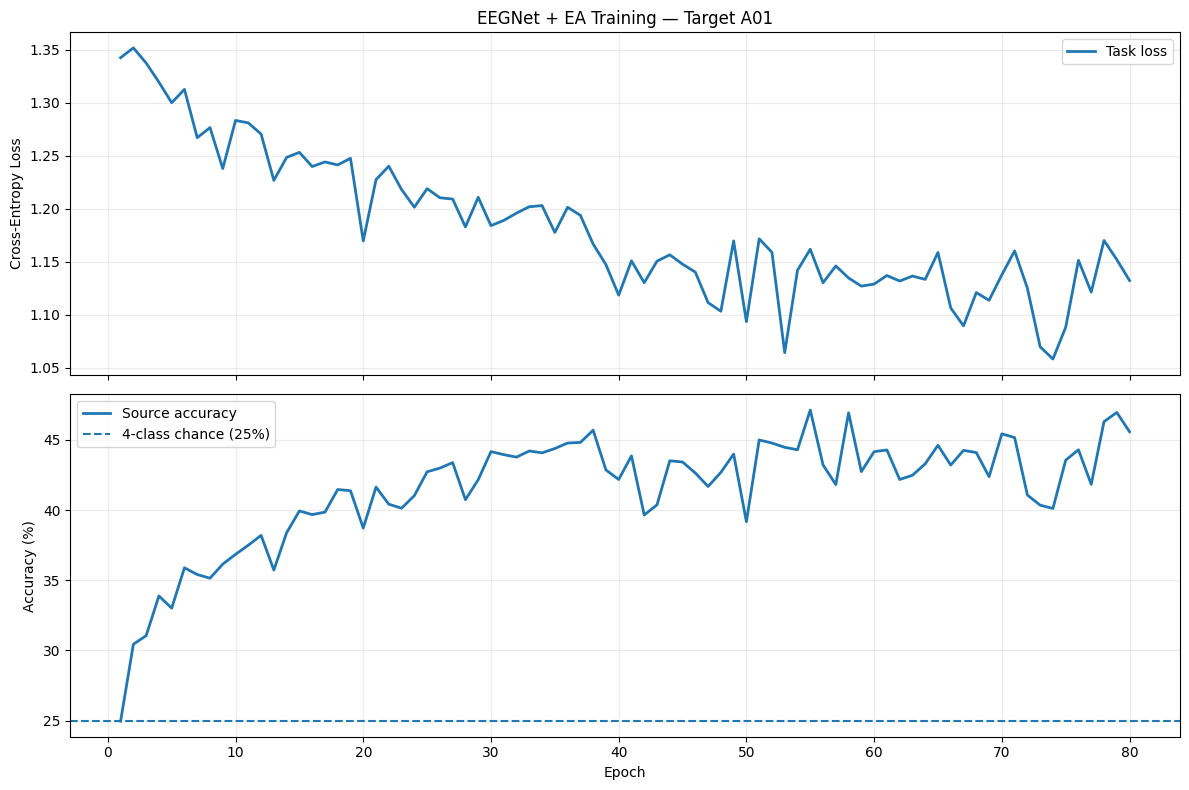

In [19]:
# ============================================================
# CELL 18 — TRAINING HISTORY
# BASELINE
# ============================================================

def plot_baseline_history(
    history,
    target_subject,
):

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 8),
        sharex=True,
    )


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    axes[0].plot(

        history["epoch"],

        history["loss_task"],

        linewidth=2,

        label="Task loss",
    )


    axes[0].set_ylabel(
        "Cross-Entropy Loss"
    )


    axes[0].set_title(

        f"EEGNet + EA Training — "
        f"Target {target_subject}"
    )


    axes[0].grid(
        alpha=0.25
    )


    axes[0].legend()


    # --------------------------------------------------------
    # SOURCE ACCURACY
    # --------------------------------------------------------

    axes[1].plot(

        history["epoch"],

        history["source_task_acc"]
        * 100,

        linewidth=2,

        label="Source accuracy",
    )


    # Chance level
    axes[1].axhline(

        25.0,

        linestyle="--",

        linewidth=1.5,

        label="4-class chance (25%)",
    )


    axes[1].set_xlabel(
        "Epoch"
    )


    axes[1].set_ylabel(
        "Accuracy (%)"
    )


    axes[1].grid(
        alpha=0.25
    )


    axes[1].legend()


    plt.tight_layout()

    plt.show()


plot_baseline_history(

    history_A01,

    "A01",
)

In [20]:
# CELL 19 — FULL 9-FOLD LOSO EXPERIMENT

targets_to_run = list(CFG.SUBJECTS)

if CFG.MAX_FOLDS is not None:
    targets_to_run = targets_to_run[:CFG.MAX_FOLDS]

all_fold_results = []
all_histories = []
all_predictions = []

for fold_idx, target_subject in enumerate(targets_to_run, start=1):
    print("=" * 80)
    print(
        f"LOSO FOLD {fold_idx}/{len(targets_to_run)} | "
        f"TARGET = {target_subject}"
    )
    print("=" * 80)

    model, history, target_metrics, fold_result = train_one_fold(
        target_subject,
        verbose=True,
    )

    all_fold_results.append(fold_result)

    history = history.copy()
    history["target_subject"] = target_subject
    all_histories.append(history)

    pred_df = pd.DataFrame({
        "target_subject": target_subject,
        "y_true": target_metrics["y_true"],
        "y_pred": target_metrics["y_pred"],
    })
    all_predictions.append(pred_df)

    fold_dir = Path(CFG.OUTPUT_DIR) / target_subject
    fold_dir.mkdir(parents=True, exist_ok=True)

    torch.save(
        model.state_dict(),
        fold_dir / "best_model.pt",
    )
    history.to_csv(
        fold_dir / "history.csv",
        index=False,
    )
    pred_df.to_csv(
        fold_dir / "predictions.csv",
        index=False,
    )
    np.save(
        fold_dir / "confusion_matrix.npy",
        target_metrics["confusion_matrix"],
    )

    print(
        f"{target_subject} | "
        f"Accuracy={fold_result['accuracy']:.4f} | "
        f"Balanced Acc={fold_result['balanced_accuracy']:.4f} | "
        f"Macro-F1={fold_result['macro_f1']:.4f}"
    )

fold_results_df = pd.DataFrame(all_fold_results)
history_df = pd.concat(all_histories, ignore_index=True)
predictions_df = pd.concat(all_predictions, ignore_index=True)

fold_results_df.to_csv(
    Path(CFG.OUTPUT_DIR) / "loso_results.csv",
    index=False,
)
history_df.to_csv(
    Path(CFG.OUTPUT_DIR) / "all_histories.csv",
    index=False,
)
predictions_df.to_csv(
    Path(CFG.OUTPUT_DIR) / "all_predictions.csv",
    index=False,
)

display(fold_results_df)

LOSO FOLD 1/1 | TARGET = A01


TARGET SUBJECT: A01

Target subject: A01
Source subjects: ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Training samples: 2296
Target samples: 287
Target used for training: False

Model device: mps
Number of trainable parameters: 105981
[A01] Epoch 001/80 | Loss=1.3590 | SourceAcc=0.2522 | LR=0.0009996
[A01] Epoch 005/80 | Loss=1.2611 | SourceAcc=0.3181 | LR=0.0009905
[A01] Epoch 010/80 | Loss=1.2702 | SourceAcc=0.3442 | LR=0.0009623
[A01] Epoch 015/80 | Loss=1.1284 | SourceAcc=0.3590 | LR=0.0009166
[A01] Epoch 020/80 | Loss=1.2141 | SourceAcc=0.3782 | LR=0.0008550
[A01] Epoch 025/80 | Loss=1.1584 | SourceAcc=0.3994 | LR=0.0007800
[A01] Epoch 030/80 | Loss=1.1806 | SourceAcc=0.4155 | LR=0.0006944
[A01] Epoch 035/80 | Loss=1.1480 | SourceAcc=0.4229 | LR=0.0006016
[A01] Epoch 040/80 | Loss=1.1333 | SourceAcc=0.4142 | LR=0.0005050
[A01] Epoch 045/80 | Loss=1.1474 | SourceAcc=0.4138 | LR=0.0004084
[A01] Epoch 050/80 | Loss=1.1642 | SourceAcc=0.4233

,target_subject,n_source_subjects,source_subjects,best_epoch,best_source_accuracy,accuracy,balanced_accuracy,macro_f1
0,A01,8,"A02,A03,A04,A05,A06,A07,A08,A09",71,0.466463,0.247387,0.25,0.099162


In [21]:
# CELL 20 — AGGREGATE LOSO PERFORMANCE

metric_cols = ["accuracy", "balanced_accuracy", "macro_f1"]

summary_rows = []

for metric in metric_cols:
    summary_rows.append({
        "metric": metric,
        "mean": fold_results_df[metric].mean(),
        "std": fold_results_df[metric].std(ddof=1),
        "min": fold_results_df[metric].min(),
        "max": fold_results_df[metric].max(),
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df.to_string(index=False))

print("\nAccuracy (%):")
print(
    f"{fold_results_df['accuracy'].mean() * 100:.2f} "
    f"± {fold_results_df['accuracy'].std(ddof=1) * 100:.2f}"
)

summary_df.to_csv(
    Path(CFG.OUTPUT_DIR) / "summary_metrics.csv",
    index=False,
)

           metric     mean  std      min      max
         accuracy 0.247387  NaN 0.247387 0.247387
balanced_accuracy 0.250000  NaN 0.250000 0.250000
         macro_f1 0.099162  NaN 0.099162 0.099162

Accuracy (%):
24.74 ± nan


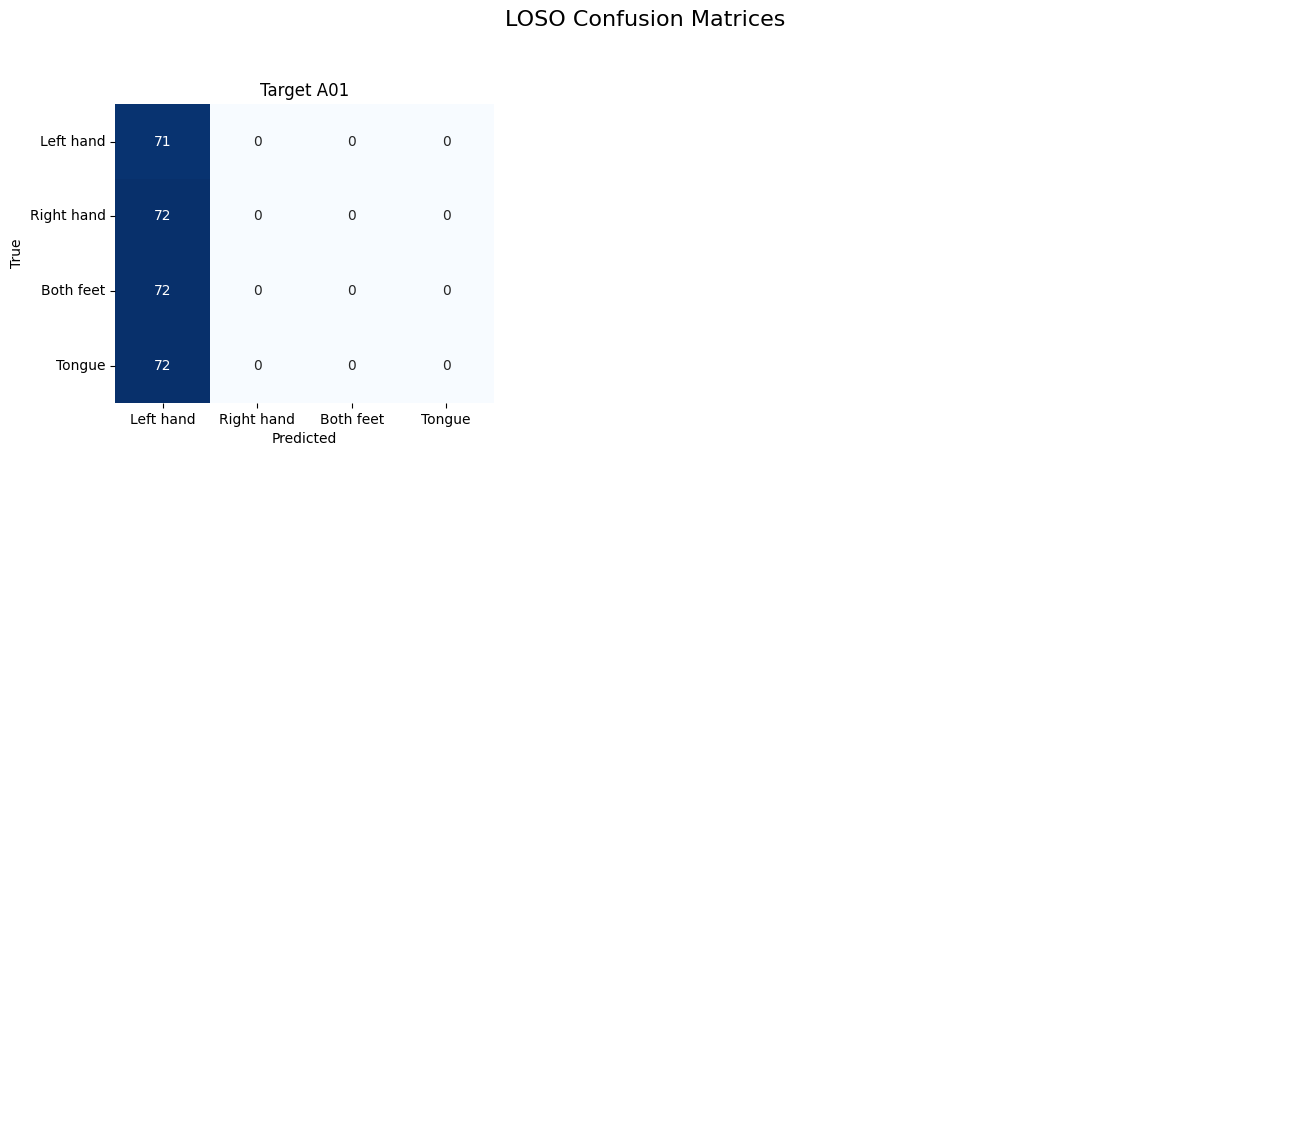

In [22]:
# CELL 21 — CONFUSION MATRICES ACROSS SUBJECTS

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for ax, sid in zip(axes.flat, targets_to_run):
    pred = predictions_df[
        predictions_df["target_subject"] == sid
    ]

    cm = confusion_matrix(
        pred["y_true"],
        pred["y_pred"],
        labels=list(range(4)),
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )

    ax.set_title(f"Target {sid}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for ax in axes.flat[len(targets_to_run):]:
    ax.axis("off")

plt.suptitle("LOSO Confusion Matrices", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
# CELL 22 — FINAL PER-SUBJECT REPORT

report_table = fold_results_df[
    [
        "target_subject",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "best_epoch",
    ]
].copy()

for col in ["accuracy", "balanced_accuracy", "macro_f1"]:
    report_table[col] *= 100.0

report_table = report_table.rename(columns={
    "target_subject": "Target",
    "accuracy": "Accuracy (%)",
    "balanced_accuracy": "Balanced Acc. (%)",
    "macro_f1": "Macro F1 (%)",
    "best_epoch": "Best Epoch",
})

display(report_table)

,Target,Accuracy (%),Balanced Acc. (%),Macro F1 (%),Best Epoch
0,A01,24.738676,25.0,9.916201,71


## 6. Strict-inductive variant

For a stricter unseen-user study, avoid using target test trials to estimate EA and avoid including target samples in the domain loss:

```python
CFG.EA_TARGET_MODE = "identity"
CFG.USE_TARGET_DOMAIN_SAMPLES = False
```

A stronger practical adaptation protocol is to create a target calibration split containing unlabeled EEG for EA and/or a small labeled calibration subset for supervised fine-tuning, then evaluate on a disjoint target test subset.

## 7. Recommended ablation study

To establish whether each component actually helps, compare the same LOSO folds under:

1. EEGNet only
2. EEGNet + EA
3. EEGNet + DANN
4. EEGNet + EA + DANN

Report mean ± SD across subjects for accuracy, balanced accuracy, and macro-F1.

The DANN branch is adversarial: it pushes the feature extractor toward representations that are useful for motor imagery while being less predictive of subject identity.

Because the domain classifier here predicts **subject ID**, it is a multi-class domain discriminator. Canonical binary DANN often uses source-vs-target domain labels; this notebook follows the subject-ID design requested in the prompt.